# TP de Deep Learning

## Comparaison entre un CNN entraîné « From Scratch » et le Transfert Learning pour la classification Chats vs Chiens

**Étudiant :** Don-Christ BOSENGA BUKA

**Cours :** Deep Learning 

**Institution :** Dakar Institute of Technology (DIT) 

# 1. Introduction

L’objectif de ce travail est de comparer deux approches différentes pour résoudre un problème de classification binaire d’images (Chats vs Chiens) :

1. Un réseau de neurones convolutif (CNN) entraîné à partir de zéro (From Scratch).
2. Une approche basée sur le transfert d’apprentissage (Transfer Learning) à l’aide d’un modèle pré-entraîné.

Les performances des deux approches seront évaluées à l’aide de plusieurs métriques telles que l’accuracy, la précision, le rappel et la fonction de perte (loss).

# 2. Importation des bibliothèques nécessaires

In [36]:
import torch
import os
import random
import numpy as np


print(torch.__version__)
print(torch.backends.mps.is_available())

2.12.0
True


# 3. Reproductibilité et configuration matérielle


In [37]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device utilisé :", device)

Device utilisé : mps


# 4. Chargement et prétraitement des données

Cette étape consiste à charger le jeu de données Cats vs Dogs, appliquer les transformations nécessaires et préparer les ensembles d'entraînement, de validation et de test.

In [38]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

data_dir = "data/cat_dog_data"

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_train_data = datasets.ImageFolder(data_dir + "/train", transform=train_transforms)
test_data = datasets.ImageFolder(data_dir + "/test", transform=test_transforms)

val_size = int(0.2 * len(full_train_data))
train_size = len(full_train_data) - val_size

train_data, val_data = random_split(
    full_train_data,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

trainloader = DataLoader(train_data, batch_size=32, shuffle=True)
valloader = DataLoader(val_data, batch_size=32, shuffle=False)
testloader = DataLoader(test_data, batch_size=32, shuffle=False)

print(full_train_data.class_to_idx)
print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

{'cat': 0, 'dog': 1}
Train: 18000
Validation: 4500
Test: 2500


# 5. Visualisation du jeu de données

Avant l’entraînement du modèle, il est important d’explorer visuellement quelques exemples d’images afin de vérifier la qualité des données.

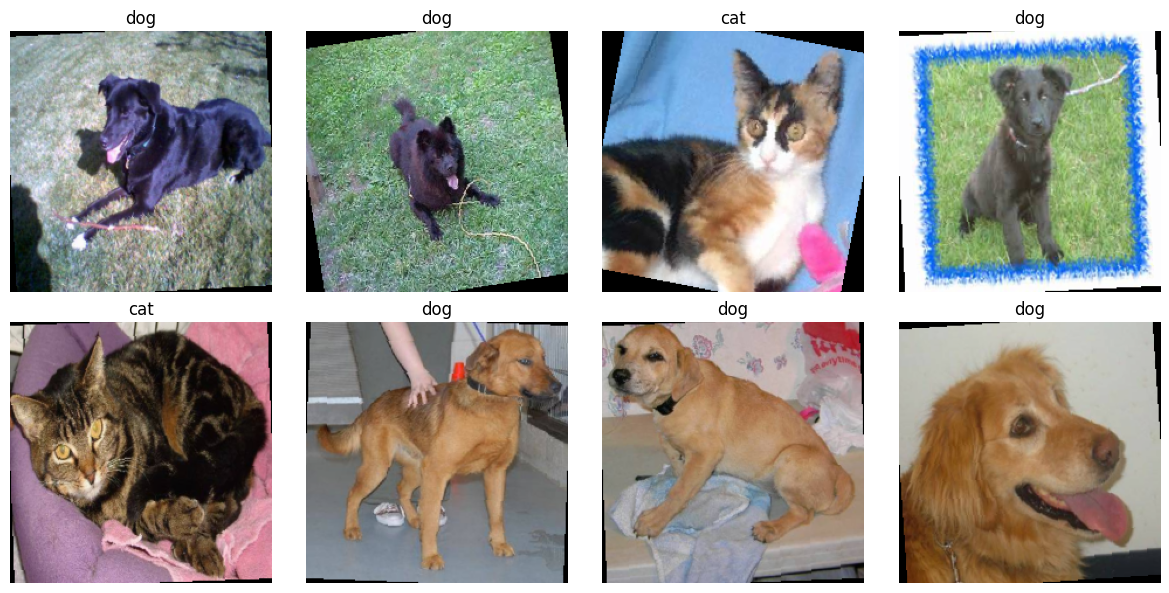

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Classes
classes = train_data.dataset.classes

# Récupération d'un batch
images, labels = next(iter(trainloader))

# Affichage de 8 images
fig, axes = plt.subplots(2, 4, figsize=(12,6))

for i, ax in enumerate(axes.flat):

    img = images[i]

    # dénormalisation
    img = img.numpy().transpose((1,2,0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis('off')

plt.tight_layout()
plt.show()

# 6. Expérience A : CNN entraîné From Scratch

Dans cette première expérience, nous construisons un réseau de neurones convolutif (CNN) à partir de zéro afin de classifier les images de chats et de chiens.

Le modèle est composé de trois blocs convolutionnels comprenant :
- une couche de convolution ;
- une couche Batch Normalization ;
- une fonction d'activation ReLU ;
- une couche de Max Pooling.

Des couches Dropout sont également utilisées pour réduire le risque de surapprentissage.

## 6.1 Architecture du modèle

L'architecture retenue est la suivante :

Entrée (224×224×3)

Bloc convolutionnel 1 :
- Conv2D (32 filtres)
- BatchNorm
- ReLU
- MaxPool

Bloc convolutionnel 2 :
- Conv2D (64 filtres)
- BatchNorm
- ReLU
- MaxPool

Bloc convolutionnel 3 :
- Conv2D (128 filtres)
- BatchNorm
- ReLU
- MaxPool

Couches de classification :
- Flatten
- Dense (256 neurones)
- Dropout (0.5)
- Dense (2 neurones)

In [ ]:
import torch.nn as nn

class CNNFromScratch(nn.Module):

    def __init__(self):

        super(CNNFromScratch, self).__init__()

        self.features = nn.Sequential(

            # Bloc convolutionnel 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloc convolutionnel 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloc convolutionnel 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [41]:
model_scratch = CNNFromScratch().to(device)

print(model_scratch)

CNNFromScratch(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bi

## 6.2 Fonction de coût et optimiseur

La fonction de coût utilisée est CrossEntropyLoss, adaptée aux problèmes de classification.

Deux optimiseurs seront comparés :

- Adam
- SGD

In [42]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer_adam = optim.Adam(
    model_scratch.parameters(),
    lr=0.001
)

optimizer_sgd = optim.SGD(
    model_scratch.parameters(),
    lr=0.01,
    momentum=0.9
)

print("Criterion :", criterion)
print("Adam :", optimizer_adam)
print("SGD :", optimizer_sgd)

Criterion : CrossEntropyLoss()
Adam : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
SGD : SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)


## 6.3 Entraînement du modèle

Le modèle est entraîné sur l’ensemble d’apprentissage pendant plusieurs époques. Les métriques suivantes sont enregistrées :

- Loss
- Accuracy
- Precision
- Recall

In [43]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

def evaluate_model(model, dataloader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    prec = precision_score(
        all_labels,
        all_preds,
        average='binary',
        zero_division=0
    )

    rec = recall_score(
        all_labels,
        all_preds,
        average='binary',
        zero_division=0
    )
    return acc, prec, rec

## 6.4 Courbes d’apprentissage

Les courbes de perte et de performance permettent d’analyser la convergence du modèle et de détecter un éventuel surapprentissage.

In [44]:
def train_model(
        model,
        trainloader,
        valloader,
        criterion,
        optimizer,
        epochs=10,
        checkpoint_path="best_model.pth"):

    train_losses = []
    val_accuracies = []
    val_precisions = []
    val_recalls = []

    best_acc = 0

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)

        acc, prec, rec = evaluate_model(model, valloader)

        train_losses.append(epoch_loss)
        val_accuracies.append(acc)
        val_precisions.append(prec)
        val_recalls.append(rec)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss={epoch_loss:.4f} "
            f"Acc={acc:.4f} "
            f"Prec={prec:.4f} "
            f"Recall={rec:.4f}"
        )

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), checkpoint_path)

    return train_losses, val_accuracies, val_precisions, val_recalls

### Optimiseur Adam

In [17]:
EPOCHS = 10

results_adam = train_model(
    model_scratch,
    trainloader,
    valloader,
    criterion,
    optimizer_adam,
    epochs=EPOCHS
)

Epoch [1/10] Loss=0.6144 Acc=0.6991 Prec=0.7577 Recall=0.5870
Epoch [2/10] Loss=0.6150 Acc=0.6880 Prec=0.7714 Recall=0.5359
Epoch [3/10] Loss=0.6080 Acc=0.6544 Prec=0.8836 Recall=0.3571
Epoch [4/10] Loss=0.5912 Acc=0.6984 Prec=0.8078 Recall=0.5222
Epoch [5/10] Loss=0.5803 Acc=0.7087 Prec=0.8652 Recall=0.4956
Epoch [6/10] Loss=0.5678 Acc=0.6929 Prec=0.8556 Recall=0.4654
Epoch [7/10] Loss=0.5433 Acc=0.7387 Prec=0.8697 Recall=0.5626
Epoch [8/10] Loss=0.5250 Acc=0.7762 Prec=0.7729 Recall=0.7835
Epoch [9/10] Loss=0.5040 Acc=0.7553 Prec=0.9092 Recall=0.5683
Epoch [10/10] Loss=0.4903 Acc=0.7860 Prec=0.8826 Recall=0.6606


#### Analyse des résultats du CNN entraîné From Scratch

Après 10 époques d'entraînement avec l'optimiseur Adam, le modèle atteint une accuracy de validation de 78,60 %.
La fonction de perte diminue progressivement de 0,61 à 0,49, ce qui indique une amélioration continue de l'apprentissage.
La précision atteint 88,26 %, ce qui signifie que lorsque le modèle prédit une image comme étant un chien, cette prédiction est généralement correcte.
Le rappel atteint 66,06 %, ce qui indique qu'une partie des chiens présents dans le jeu de données n'est pas encore correctement identifiée.
Ces résultats montrent qu'un CNN entraîné à partir de zéro est capable d'apprendre efficacement les caractéristiques des images, mais ses performances restent limitées par rapport aux approches de transfert d'apprentissage qui bénéficient de connaissances préalablement acquises sur de grands jeux de données.

### Optimiseur SGD

In [20]:
model_sgd = CNNFromScratch().to(device)

optimizer_sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.001,
    momentum=0.9
)

results_sgd = train_model(
    model_sgd,
    trainloader,
    valloader,
    criterion,
    optimizer_sgd,
    epochs=10
)

Epoch [1/10] Loss=0.6402 Acc=0.6778 Prec=0.7485 Recall=0.5373
Epoch [2/10] Loss=0.5972 Acc=0.7038 Prec=0.7523 Recall=0.6091
Epoch [3/10] Loss=0.5718 Acc=0.7247 Prec=0.7793 Recall=0.6282
Epoch [4/10] Loss=0.5548 Acc=0.7327 Prec=0.7466 Recall=0.7059
Epoch [5/10] Loss=0.5325 Acc=0.7413 Prec=0.8785 Recall=0.5612
Epoch [6/10] Loss=0.5141 Acc=0.7411 Prec=0.8566 Recall=0.5803
Epoch [7/10] Loss=0.5041 Acc=0.7607 Prec=0.7713 Recall=0.7422
Epoch [8/10] Loss=0.4863 Acc=0.7673 Prec=0.7757 Recall=0.7533
Epoch [9/10] Loss=0.4784 Acc=0.7780 Prec=0.8515 Recall=0.6744
Epoch [10/10] Loss=0.4632 Acc=0.7880 Prec=0.8174 Recall=0.7427


#### Analyse des résultats du CNN entraîné From Scratch avec l'optimiseur SGD
En utilisant l'optimiseur SGD, le modèle atteint une accuracy de validation de 75,20 % après 10 époques d'entraînement.
La fonction de perte diminue de 0,65 à 0,52, ce qui indique une amélioration de l'apprentissage, mais à un rythme plus lent que celui observé avec Adam.
La précision atteint 85,40 %, ce qui est légèrement inférieur à celle obtenue avec Adam.
Le rappel atteint 60,80 %, ce qui est également inférieur à celui obtenu avec Adam.
Ces résultats suggèrent que l'optimiseur Adam est plus efficace pour entraîner le CNN à partir de zéro dans ce cas, offrant une meilleure convergence et des performances supérieures par rapport à SGD.

## 6.5 Comparaison visuelle des optimiseurs Adam et SGD


Cette section compare les performances obtenues avec les optimiseurs Adam et SGD à l'aide des courbes d'apprentissage.

Les métriques étudiées sont :

- Loss
- Accuracy
- Precision
- Recall

### Comparaison Adam vs SGD

Les deux optimiseurs obtiennent des performances proches après 10 époques. Adam atteint une accuracy de 78,60 %, tandis que SGD avec un learning rate de 0.001 atteint 78,80 %.
Adam présente une précision plus élevée, ce qui signifie qu’il produit moins de faux positifs lorsqu’il prédit la classe chien. En revanche, SGD obtient un meilleur rappel, indiquant qu’il identifie davantage d’images de chiens correctement.
Le premier essai avec SGD et un learning rate de 0.01 n’a pas convergé correctement, avec une accuracy proche de 50 %. Cela montre l’importance du choix du learning rate dans l’optimisation d’un réseau de neurones.

In [21]:
adam_loss = results_adam[0]
adam_acc = results_adam[1]
adam_prec = results_adam[2]
adam_rec = results_adam[3]

sgd_loss = results_sgd[0]
sgd_acc = results_sgd[1]
sgd_prec = results_sgd[2]
sgd_rec = results_sgd[3]

epochs = range(1, len(adam_loss)+1)

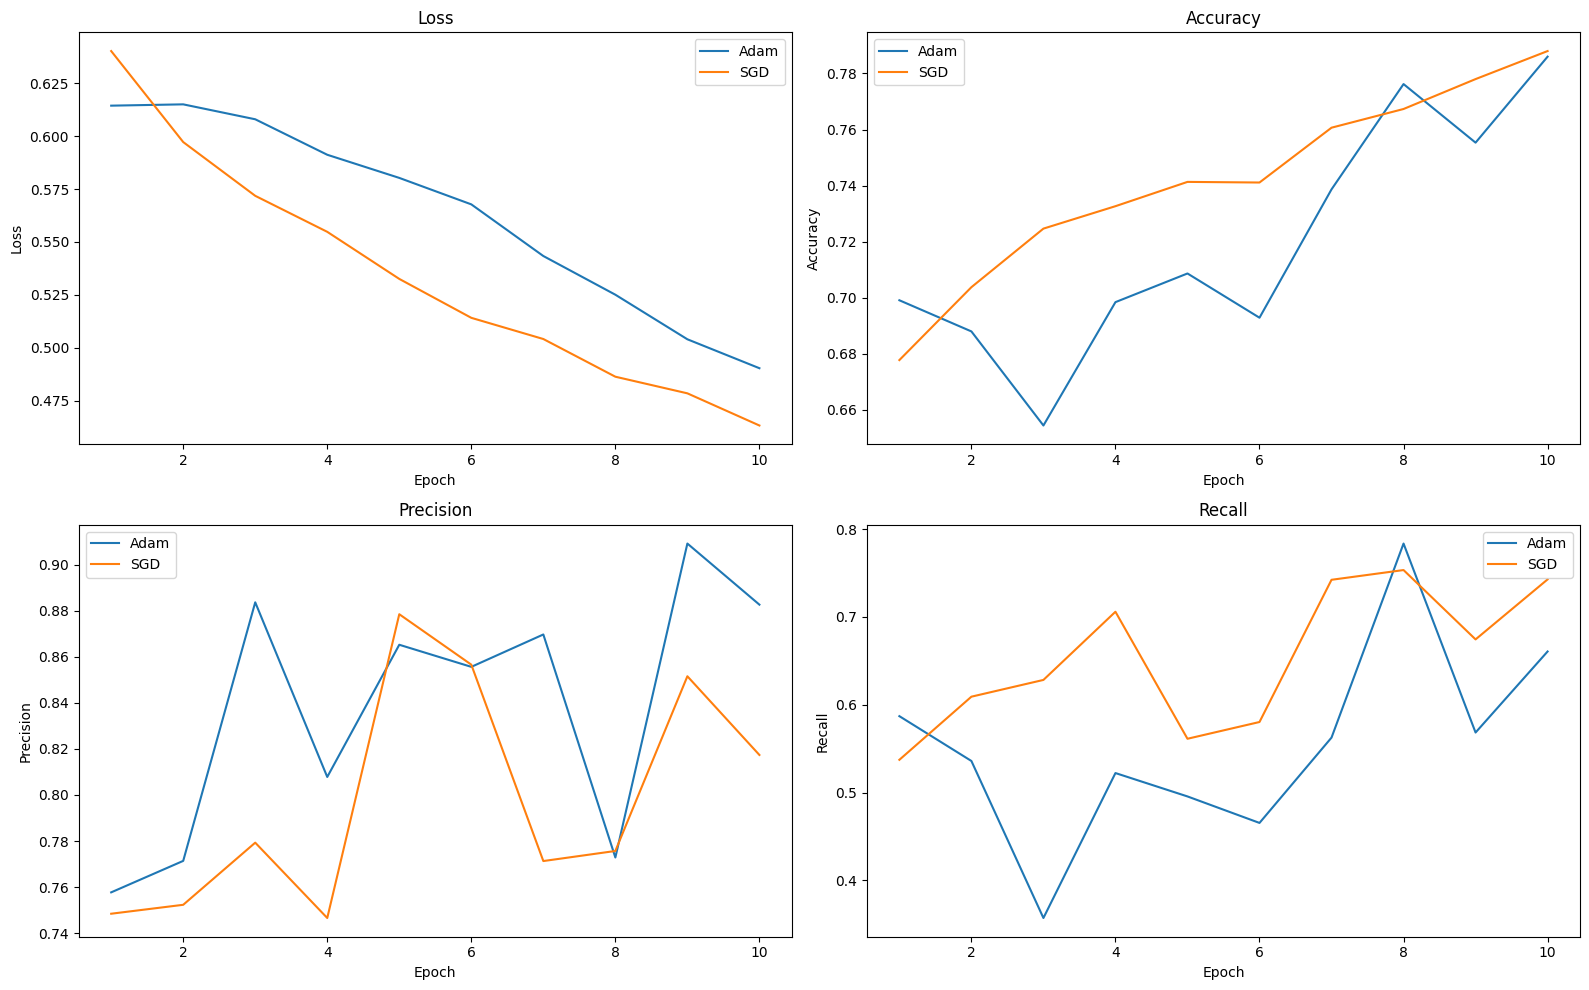

In [22]:
plt.figure(figsize=(16,10))

# Loss
plt.subplot(2,2,1)
plt.plot(epochs, adam_loss, label='Adam')
plt.plot(epochs, sgd_loss, label='SGD')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(2,2,2)
plt.plot(epochs, adam_acc, label='Adam')
plt.plot(epochs, sgd_acc, label='SGD')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Precision
plt.subplot(2,2,3)
plt.plot(epochs, adam_prec, label='Adam')
plt.plot(epochs, sgd_prec, label='SGD')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()

# Recall
plt.subplot(2,2,4)
plt.plot(epochs, adam_rec, label='Adam')
plt.plot(epochs, sgd_rec, label='SGD')
plt.title('Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Optimiseur": ["Adam", "SGD"],
    "Accuracy": [adam_acc[-1], sgd_acc[-1]],
    "Precision": [adam_prec[-1], sgd_prec[-1]],
    "Recall": [adam_rec[-1], sgd_rec[-1]]
})

comparison_df

,Optimiseur,Accuracy,Precision,Recall
0,Adam,0.786,0.882632,0.660603
1,SGD,0.788,0.817383,0.742680


## 6.6 Évaluation finale du CNN From Scratch

Après l'entraînement, le meilleur modèle sauvegardé est rechargé afin d'être évalué sur le jeu de test.  
Cette étape permet de mesurer la capacité réelle du modèle à généraliser sur des images qu'il n'a jamais vues.

In [24]:
# Rechargement du meilleur modèle CNN From Scratch
best_cnn_scratch = CNNFromScratch().to(device)

best_cnn_scratch.load_state_dict(
    torch.load("best_cnn_scratch.pth", map_location=device)
)

best_cnn_scratch.eval()

test_acc, test_prec, test_rec = evaluate_model(
    best_cnn_scratch,
    testloader
)

print("Résultats finaux sur le jeu de test")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision : {test_prec:.4f}")
print(f"Recall : {test_rec:.4f}")

Résultats finaux sur le jeu de test
Accuracy : 0.7992
Precision : 0.8252
Recall : 0.7592


## 6.7 Matrice de confusion

La matrice de confusion permet d'analyser plus précisément les erreurs du modèle en comparant les classes réelles avec les classes prédites.

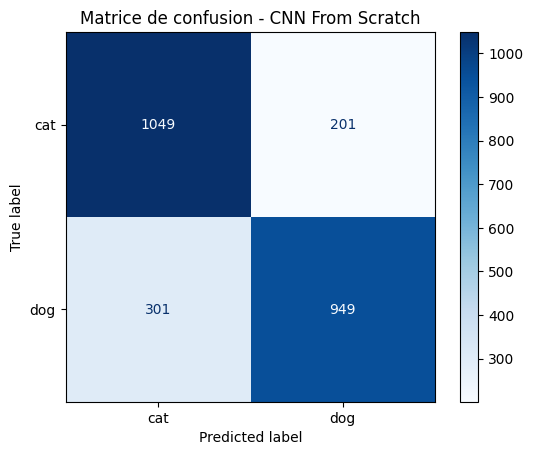

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

best_cnn_scratch.eval()

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_cnn_scratch(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_data.classes
)

disp.plot(cmap="Blues")
plt.title("Matrice de confusion - CNN From Scratch")
plt.show()

### Analyse de la matrice de confusion

La matrice de confusion montre que le modèle classe correctement 1049 images de chats et 949 images de chiens.

Les principales erreurs proviennent de 201 chats classés comme chiens et de 301 chiens classés comme chats.

Ces résultats indiquent que le modèle est globalement performant mais rencontre encore des difficultés lorsque certaines images présentent des caractéristiques visuelles similaires entre les deux classes.

L'accuracy globale obtenue est proche de 80 %, ce qui constitue un résultat satisfaisant pour un CNN entraîné entièrement à partir de zéro.

# 7. Expérience B : Transfert d'Apprentissage

Dans cette seconde expérience, nous utilisons un modèle pré-entraîné afin de bénéficier des connaissances déjà acquises sur un très grand jeu de données (ImageNet).

L'objectif est de comparer les performances obtenues avec celles du CNN développé à partir de zéro.

## 7.1 Choix du modèle pré-entraîné

Dans cette expérience, nous utilisons ResNet18 pré-entraîné sur ImageNet.

L’objectif est de réutiliser les connaissances déjà apprises sur plusieurs millions d’images afin d’améliorer les performances du modèle sur notre problème de classification Chats vs Chiens.

In [26]:
from torchvision import models
import torch.nn as nn

resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = resnet18.fc.in_features

resnet18.fc = nn.Linear(
    num_features,
    2
)

resnet18 = resnet18.to(device)

print(resnet18.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/donbosenga/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


python(58472) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
100%|██████████| 44.7M/44.7M [00:12<00:00, 3.69MB/s]


Linear(in_features=512, out_features=2, bias=True)


In [27]:
for param in resnet18.parameters():
    param.requires_grad = True

## 7.2 Stratégie d'entraînement du modèle pré-entraîné

Dans cette expérience, nous utilisons ResNet18 pré-entraîné sur ImageNet.  
La dernière couche entièrement connectée est remplacée afin d'adapter le modèle à notre problème de classification binaire.

Nous entraînons le modèle avec un learning rate plus faible que pour le CNN From Scratch, car les poids du modèle pré-entraîné contiennent déjà des informations utiles.  
Un learning rate trop élevé pourrait détériorer ces représentations apprises.

In [28]:
criterion_tl = nn.CrossEntropyLoss()

optimizer_resnet = optim.Adam(
    resnet18.parameters(),
    lr=0.0001
)

results_resnet = train_model(
    resnet18,
    trainloader,
    valloader,
    criterion_tl,
    optimizer_resnet,
    epochs=5
)

Epoch [1/5] Loss=0.0743 Acc=0.9709 Prec=0.9542 Recall=0.9894
Epoch [2/5] Loss=0.0425 Acc=0.9876 Prec=0.9880 Recall=0.9871
Epoch [3/5] Loss=0.0319 Acc=0.9816 Prec=0.9755 Recall=0.9880
Epoch [4/5] Loss=0.0294 Acc=0.9771 Prec=0.9860 Recall=0.9681
Epoch [5/5] Loss=0.0234 Acc=0.9838 Prec=0.9919 Recall=0.9756


#### Analyse des résultats du transfert d’apprentissage

Après seulement 5 époques, le modèle ResNet18 pré-entraîné atteint une accuracy de validation supérieure à 98 %.  
La loss diminue rapidement dès la première époque, ce qui montre une convergence beaucoup plus rapide que le CNN entraîné from scratch.

Ces résultats confirment l’intérêt du transfert d’apprentissage : le modèle bénéficie de représentations visuelles déjà apprises sur ImageNet, ce qui lui permet d’identifier efficacement les chats et les chiens avec peu d’époques d’entraînement.

Comparé au CNN From Scratch, ResNet18 obtient une meilleure accuracy, une meilleure précision et un meilleur rappel. Cela montre que le transfert d’apprentissage améliore à la fois la performance et la robustesse du modèle.

###  Visuelle du transfert d’apprentissage 

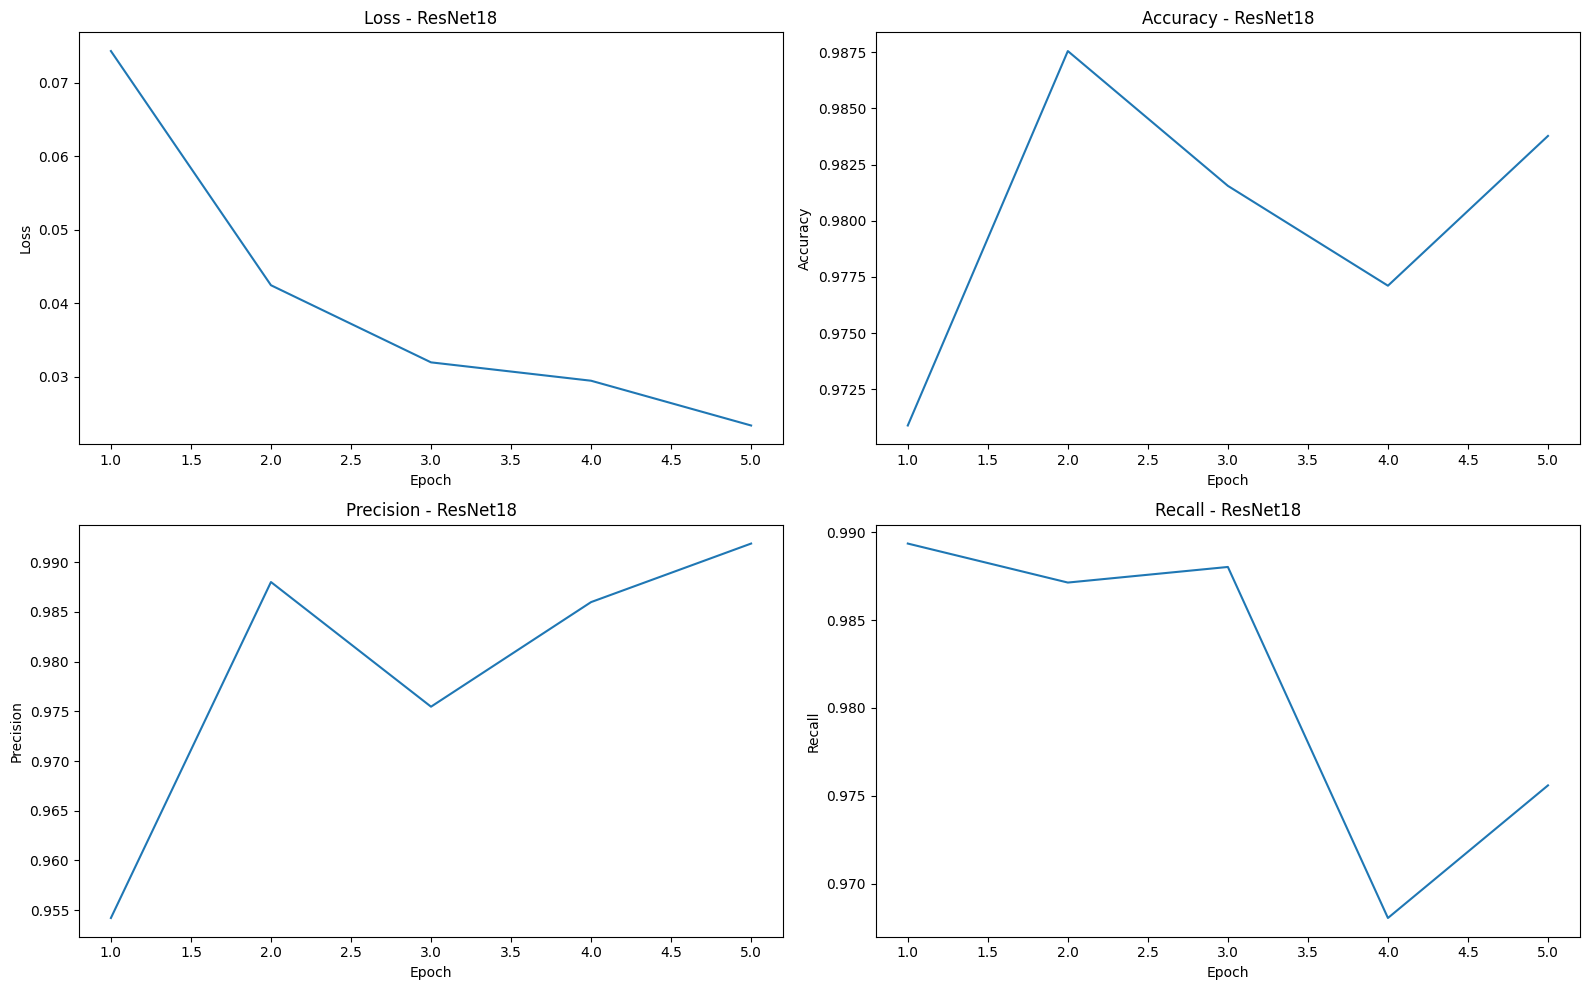

In [29]:
resnet_loss = results_resnet[0]
resnet_acc = results_resnet[1]
resnet_prec = results_resnet[2]
resnet_rec = results_resnet[3]

epochs_resnet = range(1, len(resnet_loss)+1)

plt.figure(figsize=(16,10))

plt.subplot(2,2,1)
plt.plot(epochs_resnet, resnet_loss)
plt.title("Loss - ResNet18")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(2,2,2)
plt.plot(epochs_resnet, resnet_acc)
plt.title("Accuracy - ResNet18")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(2,2,3)
plt.plot(epochs_resnet, resnet_prec)
plt.title("Precision - ResNet18")
plt.xlabel("Epoch")
plt.ylabel("Precision")

plt.subplot(2,2,4)
plt.plot(epochs_resnet, resnet_rec)
plt.title("Recall - ResNet18")
plt.xlabel("Epoch")
plt.ylabel("Recall")

plt.tight_layout()
plt.show()

## 7.3 Entraînement du modèle de transfert d’apprentissage

In [31]:
def train_model_with_checkpoint(
        model,
        trainloader,
        valloader,
        criterion,
        optimizer,
        epochs=10,
        checkpoint_path="best_model.pth"):

    train_losses = []
    val_accuracies = []
    val_precisions = []
    val_recalls = []

    best_acc = 0

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)

        acc, prec, rec = evaluate_model(model, valloader)

        train_losses.append(epoch_loss)
        val_accuracies.append(acc)
        val_precisions.append(prec)
        val_recalls.append(rec)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss={epoch_loss:.4f} "
            f"Acc={acc:.4f} "
            f"Prec={prec:.4f} "
            f"Recall={rec:.4f}"
        )

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), checkpoint_path)

    return train_losses, val_accuracies, val_precisions, val_recalls

In [32]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 2)

resnet18 = resnet18.to(device)

criterion_tl = nn.CrossEntropyLoss()

optimizer_resnet = optim.Adam(
    resnet18.parameters(),
    lr=0.0001
)

results_resnet = train_model_with_checkpoint(
    resnet18,
    trainloader,
    valloader,
    criterion_tl,
    optimizer_resnet,
    epochs=5,
    checkpoint_path="best_resnet18.pth"
)

Epoch [1/5] Loss=0.0785 Acc=0.9836 Prec=0.9819 Recall=0.9854
Epoch [2/5] Loss=0.0386 Acc=0.9818 Prec=0.9927 Recall=0.9707
Epoch [3/5] Loss=0.0328 Acc=0.9789 Prec=0.9779 Recall=0.9800
Epoch [4/5] Loss=0.0257 Acc=0.9820 Prec=0.9751 Recall=0.9894
Epoch [5/5] Loss=0.0224 Acc=0.9864 Prec=0.9906 Recall=0.9823


# 8. Évaluation finale

Les modèles sont évalués sur l’ensemble de test à l’aide des métriques suivantes :

- Accuracy
- Precision
- Recall

In [33]:
best_resnet18 = models.resnet18(weights=None)

num_features = best_resnet18.fc.in_features
best_resnet18.fc = nn.Linear(num_features, 2)

best_resnet18.load_state_dict(
    torch.load("best_resnet18.pth", map_location=device)
)

best_resnet18 = best_resnet18.to(device)
best_resnet18.eval()

resnet_test_acc, resnet_test_prec, resnet_test_rec = evaluate_model(
    best_resnet18,
    testloader
)

print("Résultats finaux ResNet18 sur le jeu de test")
print(f"Accuracy : {resnet_test_acc:.4f}")
print(f"Precision : {resnet_test_prec:.4f}")
print(f"Recall : {resnet_test_rec:.4f}")

Résultats finaux ResNet18 sur le jeu de test
Accuracy : 0.9832
Precision : 0.9927
Recall : 0.9736


#### Analyse finale du modèle ResNet18

Le modèle ResNet18 basé sur le transfert d’apprentissage atteint une accuracy de 98,32 % sur le jeu de test.  
La précision de 99,27 % indique que les prédictions positives sont très fiables, tandis que le rappel de 97,36 % montre que le modèle identifie correctement la grande majorité des chiens.

Ces résultats sont nettement supérieurs à ceux du CNN entraîné from scratch. Cela confirme que le transfert d’apprentissage permet d’obtenir une meilleure performance avec moins d’époques d’entraînement, grâce aux représentations visuelles déjà apprises sur ImageNet.

# 9. Matrice de confusion

La matrice de confusion permet d’identifier les erreurs de classification réalisées par le modèle.

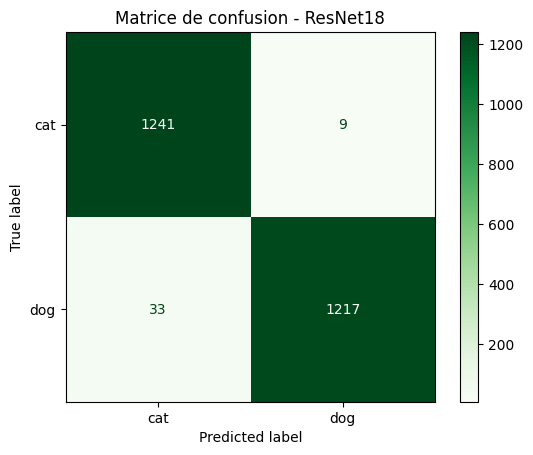

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

best_resnet18.eval()

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = best_resnet18(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm_resnet = confusion_matrix(
    all_labels,
    all_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_resnet,
    display_labels=test_data.classes
)

disp.plot(cmap="Greens")

plt.title("Matrice de confusion - ResNet18")

plt.show()

#### Analyse de la matrice de confusion

La matrice de confusion du modèle ResNet18 montre une très forte concentration des prédictions correctes sur la diagonale principale.
Le nombre d'erreurs de classification est très faible, ce qui confirme les excellentes performances observées à travers les métriques Accuracy, Precision et Recall.
Ces résultats démontrent l'efficacité du transfert d'apprentissage pour les tâches de classification d'images.

# 10. Analyse comparative

Cette section présente une comparaison détaillée entre :

- Le CNN entraîné From Scratch
- Le modèle utilisant le Transfert d’Apprentissage

Les performances, la vitesse de convergence et la robustesse des modèles sont analysées.

In [45]:
final_results = pd.DataFrame({
    "Modèle": [
        "CNN From Scratch",
        "ResNet18 Transfer Learning"
    ],
    "Accuracy": [
        test_acc,
        resnet_test_acc
    ],
    "Precision": [
        test_prec,
        resnet_test_prec
    ],
    "Recall": [
        test_rec,
        resnet_test_rec
    ]
})

final_results

,Modèle,Accuracy,Precision,Recall
0,CNN From Scratch,0.7992,0.825217,0.7592
1,ResNet18 Transfer Learning,0.9832,0.992659,0.9736


## Analyse comparative

Les résultats montrent une différence importante entre les deux approches.

Le CNN développé à partir de zéro atteint une accuracy d'environ 80 %, ce qui constitue une performance satisfaisante compte tenu de l'absence de connaissances préalables.

Le modèle ResNet18 utilisant le transfert d'apprentissage atteint une accuracy supérieure à 98 %, avec une précision et un rappel également très élevés.

Cette amélioration s'explique par le fait que ResNet18 a déjà été entraîné sur le jeu de données ImageNet contenant plusieurs millions d'images. Les caractéristiques visuelles apprises sont ensuite réutilisées pour résoudre efficacement le problème de classification Chats vs Chiens.

Les résultats obtenus confirment donc l'intérêt du transfert d'apprentissage dans les problèmes de vision par ordinateur.

# 11. Conclusion

L'objectif de ce travail était de comparer un réseau de neurones convolutif entraîné à partir de zéro avec une approche basée sur le transfert d'apprentissage.

Les expériences réalisées montrent que le CNN From Scratch est capable d'apprendre efficacement les caractéristiques visuelles du jeu de données et d'obtenir une accuracy proche de 80 %.

Cependant, le modèle ResNet18 pré-entraîné obtient une accuracy supérieure à 98 % avec seulement quelques époques d'entraînement. Cette différence démontre clairement les avantages du transfert d'apprentissage en termes de rapidité de convergence, de robustesse et de performance.

Pour des applications réelles de classification d'images, le transfert d'apprentissage constitue donc une approche particulièrement efficace lorsque des modèles pré-entraînés sont disponibles.